In [64]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_a = pd.read_csv("/content/Airbnb_Open_Data.csv", low_memory = False)
df_a.columns = df_a.columns.str.strip().str.lower().str.replace(' ', '_') # we do three things: get rid of starting and ending space; make the column names lower-case; and replace middle spaces with '_'
currency_cols = [col for col in df_a.columns if df_a[col].astype(str).str.contains(r'\$').any()] # if any column consists of $ sign, it will be added in this column
for col in currency_cols:
    df_a[col] = (df_a[col].astype(str).str.replace('$', '', regex = False).str.replace(',', '', regex = False)) # for each of the columns containing $ sign we remove it
    df_a[col] = pd.to_numeric(df_a[col], errors = 'coerce') # convert those columns to numeric data type

df_a.isna().sum().sort_values(ascending = False)

,0
house_rules,102599
license,102597
name,102585
last_review,15893
reviews_per_month,15879
country,532
availability_365,448
minimum_nights,409
host_name,406
review_rate_number,326


In [65]:
threshold = 0.5
df_b = df_a[df_a.columns[df_a.isnull().mean() < threshold]] # removing all columns that have more than 50% missing data
df_b.columns

text_cols = df_b.select_dtypes(include = 'object').columns # include all columns of object type
exclude_cols = ['instant_bookable', 'last_review'] # upon inspection of the data, these are the two columns in the dataset that contain either boolean values or datetime values so we have to keep the missing values. Otherwise we cannot change them to their correct data type
text_cols_to_fill = [col for col in text_cols if col not in exclude_cols]
numeric_cols = df_b.select_dtypes(include = 'number').columns # include all columns of numeric data type
# print(f'text are: {text_cols_to_fill}\nnumeric are: {numeric_cols}')

df_b[text_cols_to_fill] = df_b[text_cols_to_fill].fillna('Unknown') # fill the missing values of categorical columns with an 'Unknown' category
df_b[numeric_cols] = df_b[numeric_cols].fillna(df_b[numeric_cols].median()) # fill the missing values in the numeric columns with the column median
df_b.isna().sum().sort_values(ascending = False)

/tmp/ipython-input-3888603739.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b[text_cols_to_fill] = df_b[text_cols_to_fill].fillna('Unknown') # fill the missing values of categorical columns with an 'Unknown' category
/tmp/ipython-input-3888603739.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b[numeric_cols] = df_b[numeric_cols].fillna(df_b[numeric_cols].median()) # fill the missing values in the numeric columns with the column median


,0
last_review,15893
instant_bookable,105
id,0
host_name,0
neighbourhood_group,0
host_id,0
host_identity_verified,0
lat,0
neighbourhood,0
country,0


In [66]:
cat_cols = ['host_identity_verified', 'neighbourhood_group', 'neighbourhood', 'room_type'] # converting these columns to category type since they have a limited number of repeated values
df_b[cat_cols] = df_b[cat_cols].astype('category')

# df_b['instant_bookable'].unique()
df_b['instant_bookable'] = df_b['instant_bookable'].astype('boolean')
df_b['construction_year'] = df_b['construction_year'].astype('int64')
df_b['last_review'] = pd.to_datetime(df_b['last_review'])
df = df_b.drop_duplicates()
df_b.dtypes

/tmp/ipython-input-3676516991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b[cat_cols] = df_b[cat_cols].astype('category')
/tmp/ipython-input-3676516991.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b['instant_bookable'] = df_b['instant_bookable'].astype('boolean')
/tmp/ipython-input-3676516991.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

,0
id,int64
host_id,int64
host_identity_verified,category
host_name,object
neighbourhood_group,category
neighbourhood,category
lat,float64
long,float64
country,object
country_code,object


In [67]:
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_summary[col] = len(outliers)

outlier_summary

{'id': 0,
 'host_id': 0,
 'lat': 909,
 'long': 6498,
 'construction_year': 0,
 'price': 0,
 'service_fee': 0,
 'minimum_nights': 18251,
 'number_of_reviews': 11696,
 'reviews_per_month': 7099,
 'review_rate_number': 0,
 'calculated_host_listings_count': 17702,
 'availability_365': 1}

In [68]:
#Drop 'service_fee' (It correlates 99% with price, which is data leakage)
if 'service_fee' in df.columns:
    df = df.drop(columns=['service_fee'])
    print("Dropped 'service_fee' to ensure valid prediction.")

#data has 'brookln' and 'manhatan' typos
df['neighbourhood_group'] = df['neighbourhood_group'].replace({
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan'
})

#Selecting columns we want to use for prediction excluding 'id', 'host_id', 'lat', 'long' as they don't drive price logic
target = 'price'
features = ['neighbourhood_group', 'room_type', 'construction_year',
            'minimum_nights', 'number_of_reviews', 'availability_365']

print(f"Features selected: {features}")
print(f"Target variable: {target}")

Dropped 'service_fee' to ensure valid prediction.
Features selected: ['neighbourhood_group', 'room_type', 'construction_year', 'minimum_nights', 'number_of_reviews', 'availability_365']
Target variable: price


/tmp/ipython-input-1326539501.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['neighbourhood_group'] = df['neighbourhood_group'].replace({


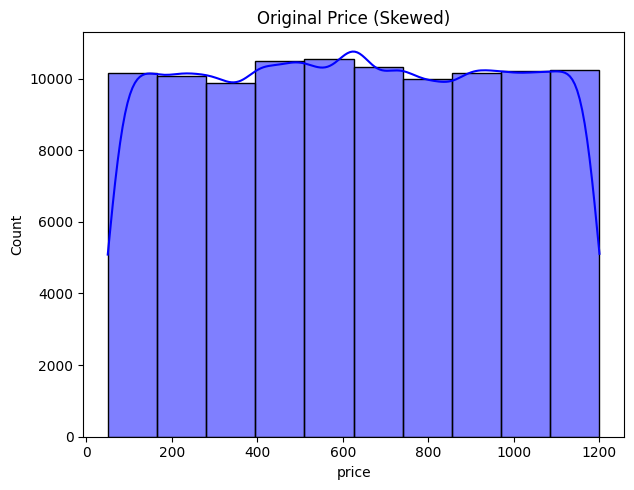

In [69]:
#Create a new target called 'log_price'
#np.log1p calculates log(1 + x) to avoid errors with zero
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=10, kde=True, color='blue')
plt.title('Original Price (Skewed)')

plt.tight_layout()
plt.show()


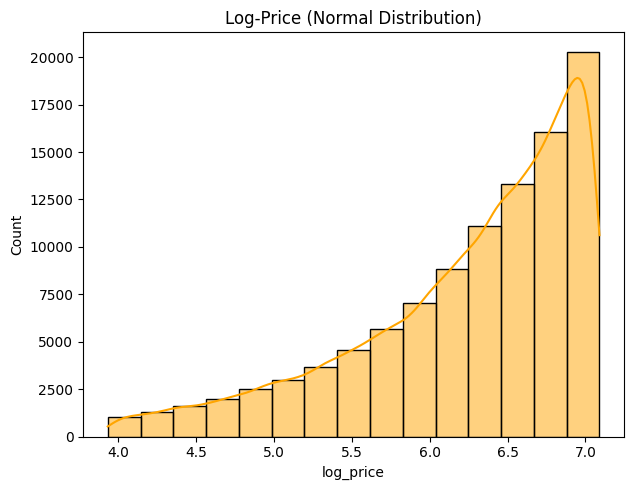

In [70]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
sns.histplot(df['log_price'], bins=15, kde=True, color='orange')
plt.title('Log-Price (Normal Distribution)')

plt.tight_layout()
plt.show()

               price  minimum_nights  number_of_reviews  availability_365
count  102058.000000   102058.000000      102058.000000     102058.000000
mean      625.352300        8.106547          27.481158        140.846264
std       331.271053       30.558319          49.534887        135.164389
min        50.000000    -1223.000000           0.000000        -10.000000
25%       341.000000        2.000000           1.000000          3.000000
50%       624.000000        3.000000           7.000000         96.000000
75%       912.000000        5.000000          30.000000        268.000000
max      1200.000000     5645.000000        1024.000000       3677.000000

Correlation Matrix:


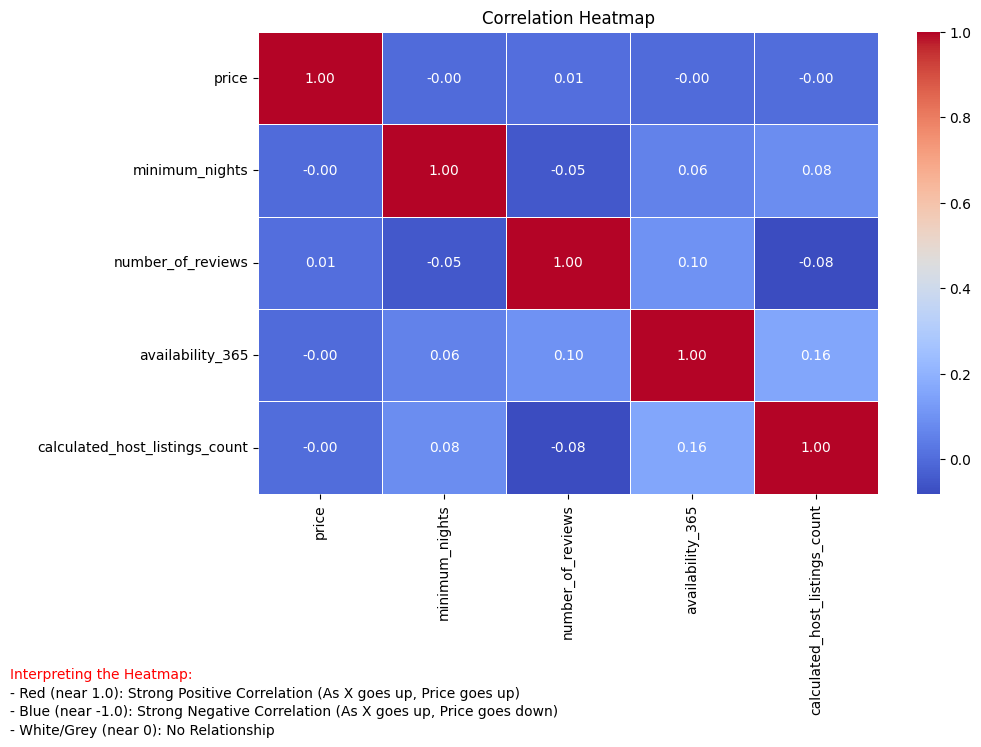

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

#DESCRIPTIVE ANALYSIS

#One Variate Analysis (Summary Statistics)
print(df[['price', 'minimum_nights', 'number_of_reviews', 'availability_365']].describe())

#Two Variable Analysis (Correlation Matrix)
print("\nCorrelation Matrix:")
plt.figure(figsize=(10, 6))

#Selecting only numeric columns for correlation
numeric_df = df[['price', 'minimum_nights', 'number_of_reviews',
                 'availability_365', 'calculated_host_listings_count']]

# Calculate correlation
corr_matrix = numeric_df.corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.text(-2, 7, "Interpreting the Heatmap:", fontsize=10, color='red')
plt.text(-2, 7.2, "- Red (near 1.0): Strong Positive Correlation (As X goes up, Price goes up)", fontsize=10, color='black')
plt.text(-2, 7.4, "- Blue (near -1.0): Strong Negative Correlation (As X goes up, Price goes down)", fontsize=10, color='black')
plt.text(-2, 7.6, "- White/Grey (near 0): No Relationship", fontsize=10, color='black')
plt.show()

In [72]:
from sklearn.model_selection import train_test_split
#Encoding and Splitting Data
#X (Features) and y (Target)
X_raw = df[features]
y = df['log_price']

#Convert text to numbers
X = pd.get_dummies(X_raw, columns=['neighbourhood_group', 'room_type'], drop_first=True)

#Split Data (80% for Training, 20% for Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")

Training Data Shape: (81646, 12)
Testing Data Shape:  (20412, 12)


------------------------------
Model Accuracy (R-Squared): 0.2417
Prediction Error (RMSE): $308.04
------------------------------


/tmp/ipython-input-967932696.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis') # Corrected 'Features' to 'Feature'


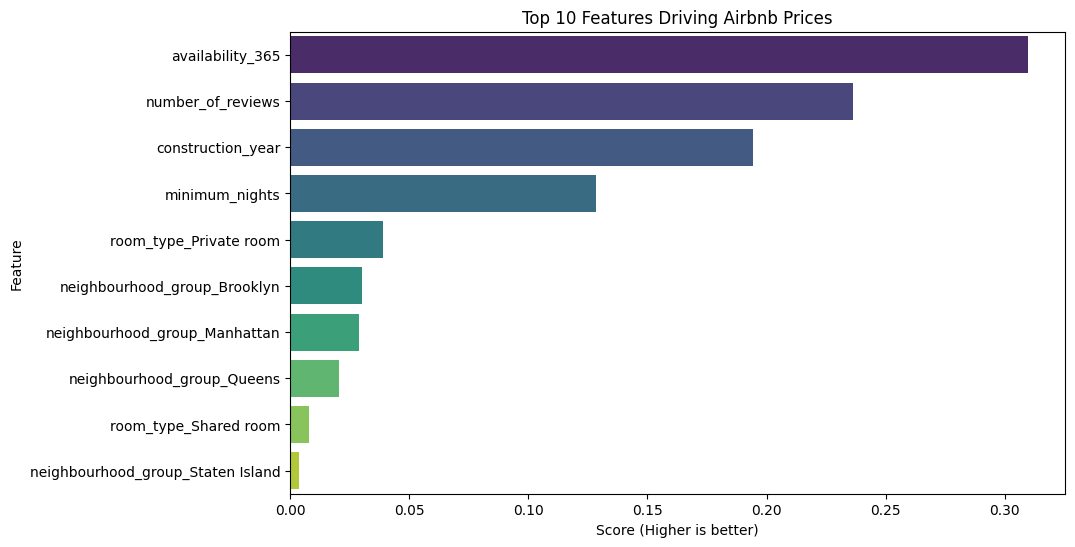


 Random Forest Model INTERPRETATION:
- Importance Score: How much the model relied on this column to guess the price.
- Unlike Linear Regression, this doesn't tell us if it lowers/raises price, just that it MATTERS.


In [77]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)

#Convert predictions back to Dollars
y_pred_dollar = np.expm1(y_pred_log)
y_test_dollar = np.expm1(y_test)

#Calculate Accuracy
r2 = r2_score(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))

print("-" * 30)
print(f"Model Accuracy (R-Squared): {r2:.4f}")
print(f"Prediction Error (RMSE): ${rmse:.2f}")
print("-" * 30)

#Feature Importance Visualization
importances = model.feature_importances_
feature_names = X_train.columns

#Creating a DataFrame for plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

#Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis') # Corrected 'Features' to 'Feature'
plt.title('Top 10 Features Driving Airbnb Prices')
plt.xlabel('Score (Higher is better)')
plt.show()

print("\n Random Forest Model INTERPRETATION:")
print("- Importance Score: How much the model relied on this column to guess the price.")
print("- Unlike Linear Regression, this doesn't tell us if it lowers/raises price, just that it MATTERS.")

In [78]:
from sklearn.linear_model import LinearRegression

#Linear Regression Model training

#Initializing the Model
model = LinearRegression()

#Training it on the Training Data
model.fit(X_train, y_train)

#Predictions on the Test Data
y_pred_log = model.predict(X_test)

#Convert predictions back from Log-Scale to Real Dollars ($)
y_pred_dollar = np.expm1(y_pred_log)
y_test_dollar = np.expm1(y_test)

print(f"Intercept (Base Log Price): {model.intercept_:.4f}")

Intercept (Base Log Price): 7.2562


In [74]:
from sklearn.metrics import mean_squared_error, r2_score

#Evaluating Performance

#Calculate Accuracy Metrics
r2 = r2_score(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))

print("-" * 30)
print(f"Model Accuracy (R-Squared): {r2:.4f}")
print(f"Prediction Error (RMSE): ${rmse:.2f}")
print("-" * 30)

#Business Impact (Coefficients)
coeffs = pd.DataFrame({'Feature': X.columns, 'Impact': model.coef_})
print("\nTop 5 Factors Influencing Price (Business Insight):")
print(coeffs.sort_values(by='Impact', key=abs, ascending=False).head(5))

print("\n INTERPRETATION:")
print("- If Impact is Positive: Feature increases price.")
print("- If Impact is Negative: Feature decreases price.")

------------------------------
Model Accuracy (R-Squared): 0.0001
Prediction Error (RMSE): $351.99
------------------------------

Top 5 Factors Influencing Price (Business Insight):
                          Feature    Impact
9            room_type_Hotel room  0.100270
8     neighbourhood_group_Unknown  0.024974
5   neighbourhood_group_Manhattan -0.018594
4    neighbourhood_group_Brooklyn -0.012565
11          room_type_Shared room -0.006104

 INTERPRETATION:
- If Impact is Positive: Feature increases price.
- If Impact is Negative: Feature decreases price.
